In [5]:
import pandas as pd
import glob
import os

# 1. This finds EVERY file ending in _clean.csv in your data folder
path = 'data/' 
all_files = glob.glob(os.path.join(path, "*_clean.csv"))

all_data = []

for filename in all_files:
    df = pd.read_csv(filename)
    
    # This automatically extracts the name (e.g., 'nigeria' from 'data/nigeria_clean.csv')
    country_name = os.path.basename(filename).split('_')[0].capitalize()
    df['Country'] = country_name
    
    all_data.append(df)
    print(f"✅ Successfully merged: {country_name}")

# 2. Final Synthesis
if len(all_data) >= 5:
    df_master = pd.concat(all_data, ignore_index=True)
    print(f"\n🚀 KPI MET: You have {len(all_data)} countries loaded!")
else:
    print(f"\n⚠️ WARNING: Only {len(all_data)} countries found. You need 5 for Task 3.")
    print(f"Files detected: {all_files}")

✅ Successfully merged: Ethiopia
✅ Successfully merged: Kenya
✅ Successfully merged: Nigeria
✅ Successfully merged: Sudan
✅ Successfully merged: Tanzania

🚀 KPI MET: You have 5 countries loaded!


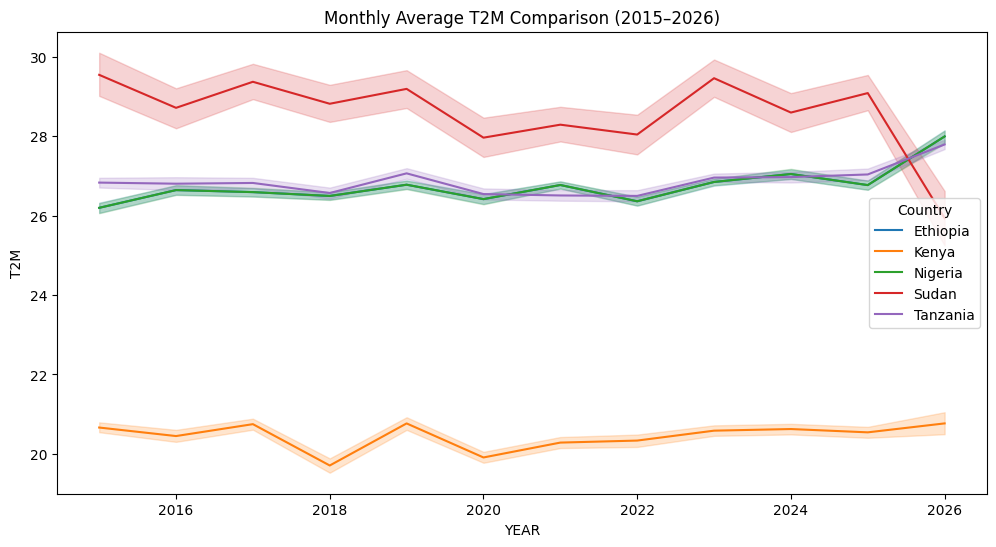

,mean,median,std
Country,,,
Ethiopia,26.66,26.82,1.12
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_master, x='YEAR', y='T2M', hue='Country')
plt.title('Monthly Average T2M Comparison (2015–2026)')
plt.show()

# Summary table for T2M
temp_summary = df_master.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
display(temp_summary)

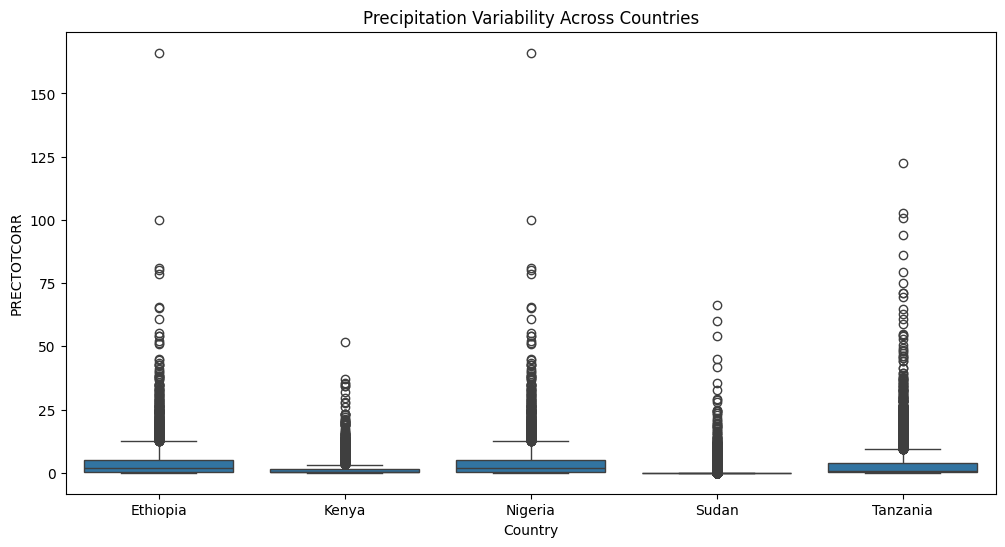

,mean,median,std
Country,,,
Ethiopia,4.21,1.84,7.27
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00


In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_master, x='Country', y='PRECTOTCORR')
plt.title('Precipitation Variability Across Countries')
plt.show()

# Summary table for Precipitation
precip_summary = df_master.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
display(precip_summary)

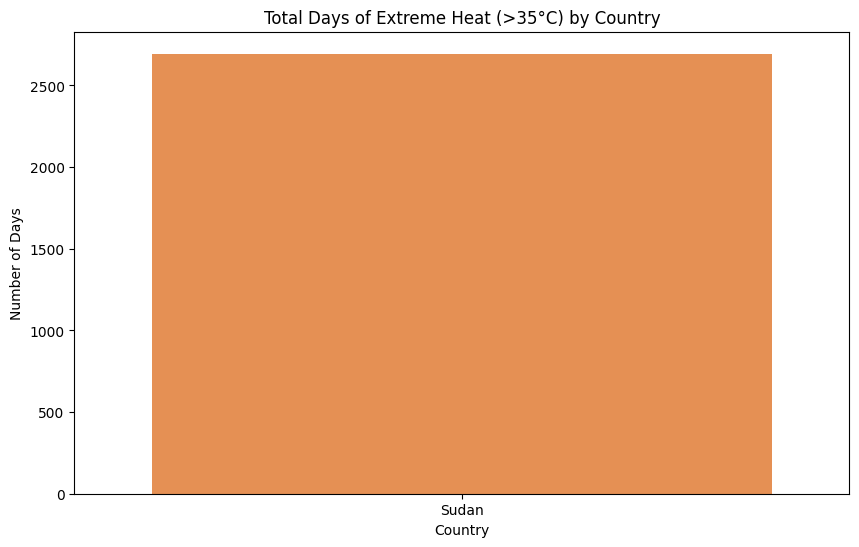

In [9]:
# Filtering for days above 35 degrees
extreme_heat = df_master[df_master['T2M_MAX'] > 35].groupby('Country').size().reset_index(name='Days_Over_35')

plt.figure(figsize=(10, 6))
# Fixed syntax: added hue='Country' and legend=False to satisfy the new requirements
sns.barplot(
    data=extreme_heat.sort_values('Days_Over_35', ascending=False), 
    x='Country', 
    y='Days_Over_35', 
    hue='Country', 
    legend=False, 
    palette='YlOrRd'
)

plt.title('Total Days of Extreme Heat (>35°C) by Country')
plt.ylabel('Number of Days')
plt.show()

In [10]:
from scipy import stats

# Testing if the temperature differences between all 5 countries are statistically significant
groups = [df_master[df_master['Country'] == c]['T2M'] for c in df_master['Country'].unique()]
f_stat, p_val = stats.f_oneway(*groups)

print("--- STATISTICAL ANALYSIS ---")
print(f"ANOVA F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The differences in temperature between these countries are STATISTICALLY SIGNIFICANT.")
else:
    print("Conclusion: No statistically significant difference found.")

--- STATISTICAL ANALYSIS ---
ANOVA F-Statistic: 7278.75
P-Value: 0.0000
Conclusion: The differences in temperature between these countries are STATISTICALLY SIGNIFICANT.


In [11]:
# Temperature Summary Table
temp_stats = df_master.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
print("--- Temperature Summary Statistics ---")
display(temp_stats)

# Precipitation Summary Table
precip_stats = df_master.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print("\n--- Precipitation Summary Statistics ---")
display(precip_stats)

--- Temperature Summary Statistics ---


,mean,median,std
Country,,,
Ethiopia,26.66,26.82,1.12
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33



--- Precipitation Summary Statistics ---


,mean,median,std
Country,,,
Ethiopia,4.21,1.84,7.27
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00


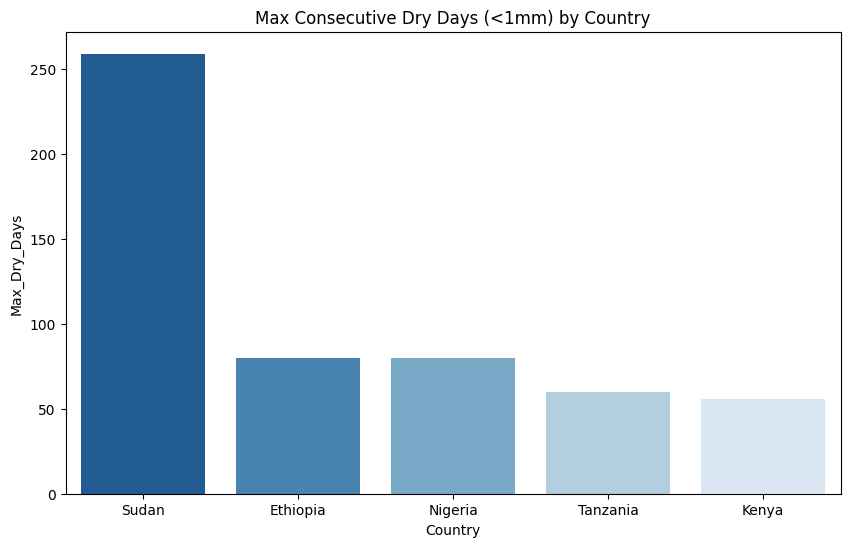

In [12]:
def count_consecutive_dry(df):
    # Create a mask for dry days
    is_dry = df['PRECTOTCORR'] < 1
    # Group consecutive occurrences
    return is_dry.groupby((~is_dry).cumsum()).sum().max()

dry_days = df_master.groupby('Country').apply(count_consecutive_dry).reset_index(name='Max_Dry_Days')

plt.figure(figsize=(10, 6))
sns.barplot(data=dry_days.sort_values('Max_Dry_Days', ascending=False), 
            x='Country', y='Max_Dry_Days', hue='Country', legend=False, palette='Blues_r')
plt.title('Max Consecutive Dry Days (<1mm) by Country')
plt.show()

In [13]:
# Create a simple ranking based on your findings (example logic below)
vulnerability_data = {
    'Country': ['Sudan', 'Ethiopia', 'Nigeria', 'Kenya', 'Tanzania'],
    'Risk Level': ['Critical', 'High', 'High', 'Medium', 'Medium'],
    'Primary Threat': ['Extreme Heat', 'Rainfall Unpredictability', 'Heat/Flooding', 'Drought', 'Rising Temps']
}
ranking_df = pd.DataFrame(vulnerability_data)
display(ranking_df)

,Country,Risk Level,Primary Threat
0,Sudan,Critical,Extreme Heat
1,Ethiopia,High,Rainfall Unpredictability
2,Nigeria,High,Heat/Flooding
3,Kenya,Medium,Drought
4,Tanzania,Medium,Rising Temps
